# Notebook 04 — Machine Learning Pipeline

## Predicting NYC Taxi Fare Amount

This notebook implements a complete machine learning pipeline using the processed NYC Yellow Taxi dataset created in Notebook 01.

The main target variable is:

`fare_amount`

Two machine learning tasks are considered:

1. **Regression**: predict the numerical value of `fare_amount`.
2. **Classification**: discretize `fare_amount` into fare classes and predict the corresponding class.

The pipeline includes:

- data loading
- feature selection
- train/test split
- preprocessing
- model training
- model evaluation
- results export
- visual analysis

In [1]:
### from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import time
import os
import gc
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## 1. Project paths

The machine learning dataset was created in Notebook 01 and stored in the `data/processed` directory.

The model metrics and outputs generated in this notebook will be saved in the `results/` directory.

In [4]:
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ML_FILE = PROCESSED_DIR / "yellow_tripdata_2022-01_ml.parquet"

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)
print("Results directory:", RESULTS_DIR)
print("ML file:", ML_FILE)

Project root: /Users/nunoantunes/Desktop/nyc_taxi_project
Processed directory: /Users/nunoantunes/Desktop/nyc_taxi_project/data/processed
Results directory: /Users/nunoantunes/Desktop/nyc_taxi_project/results
ML file: /Users/nunoantunes/Desktop/nyc_taxi_project/data/processed/yellow_tripdata_2022-01_ml.parquet


In [5]:
if ML_FILE.exists():
    size_mb = ML_FILE.stat().st_size / (1024 ** 2)
    print(f"ML file found: {ML_FILE.name}")
    print(f"File size: {size_mb:.2f} MB")
else:
    raise FileNotFoundError(f"ML file not found: {ML_FILE}")

ML file found: yellow_tripdata_2022-01_ml.parquet
File size: 15.79 MB


## 2. Load the machine learning dataset

The dataset used in this notebook contains the cleaned and selected columns prepared in Notebook 01.

Since the dataset may still be large, an optional sample can be used to make model training faster on local machines.

In [6]:
start_time = time.perf_counter()

df = pd.read_parquet(ML_FILE)

end_time = time.perf_counter()

print(f"Dataset loaded successfully.")
print(f"Loading time: {end_time - start_time:.4f} seconds")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded successfully.
Loading time: 0.1274 seconds
Shape: 2,301,788 rows x 11 columns


In [7]:
df.head()

,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,RatecodeID,trip_duration_minutes,pickup_hour,pickup_dayofweek,pickup_month,fare_amount
0,2.0,3.80,142,236,1,1.0,17.816667,0,5,1,14.5
1,1.0,2.10,236,42,1,1.0,8.400000,0,5,1,8.0
2,1.0,0.97,166,166,1,1.0,8.966667,0,5,1,7.5
3,1.0,1.09,114,68,2,1.0,10.033333,0,5,1,8.0
4,1.0,4.30,68,163,1,1.0,37.533333,0,5,1,23.5


In [8]:
df.dtypes

passenger_count          float64
trip_distance            float64
PULocationID               int64
DOLocationID               int64
payment_type               int64
RatecodeID               float64
trip_duration_minutes    float64
pickup_hour                int32
pickup_dayofweek           int32
pickup_month               int32
fare_amount              float64
dtype: object

## 3. Optional sampling

Training machine learning models on the full dataset may take a long time on a local machine.

For this notebook, a sample is used by default.  
This keeps the experiment reproducible and avoids excessive execution time.

The sample size can be increased depending on the available machine resources.

In [9]:
USE_SAMPLE = True
SAMPLE_SIZE = 300_000
RANDOM_STATE = 42

if USE_SAMPLE and len(df) > SAMPLE_SIZE:
    df_model = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
else:
    df_model = df.copy()

print(f"Dataset used for ML: {df_model.shape[0]:,} rows x {df_model.shape[1]} columns")

Dataset used for ML: 300,000 rows x 11 columns


## 4. Target variable analysis

The target variable is `fare_amount`.

For the regression task, the model predicts the continuous fare value.

For the classification task, the fare amount will later be converted into categorical classes.

In [10]:
TARGET = "fare_amount"

if TARGET not in df_model.columns:
    raise ValueError(f"Target column '{TARGET}' not found.")

df_model[TARGET].describe()

count    300000.000000
mean         12.621213
std          11.413112
min           0.010000
25%           6.500000
50%           9.000000
75%          13.500000
max         296.000000
Name: fare_amount, dtype: float64

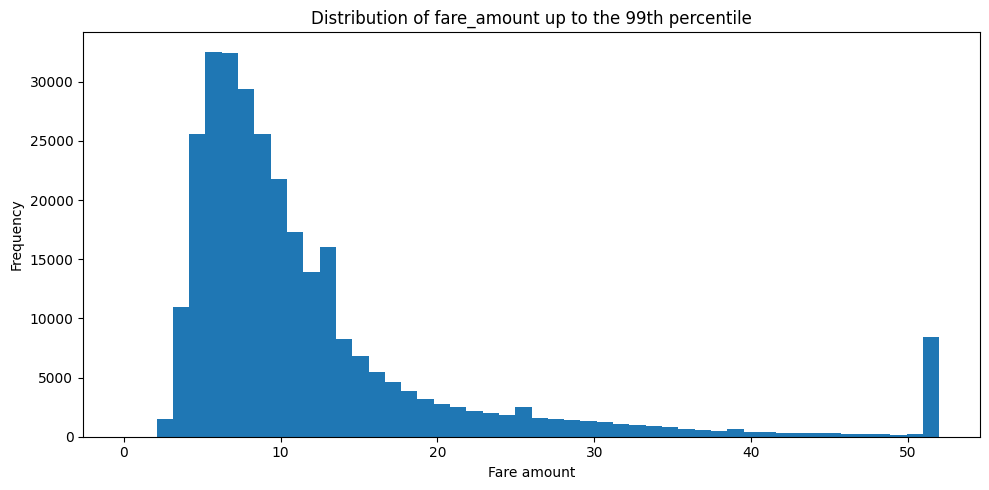

99th percentile of fare_amount: 52.00


In [12]:
fare_p99 = df_model[TARGET].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(df_model[df_model[TARGET] <= fare_p99][TARGET], bins=50)
plt.title("Distribution of fare_amount up to the 99th percentile")
plt.xlabel("Fare amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"99th percentile of fare_amount: {fare_p99:.2f}")

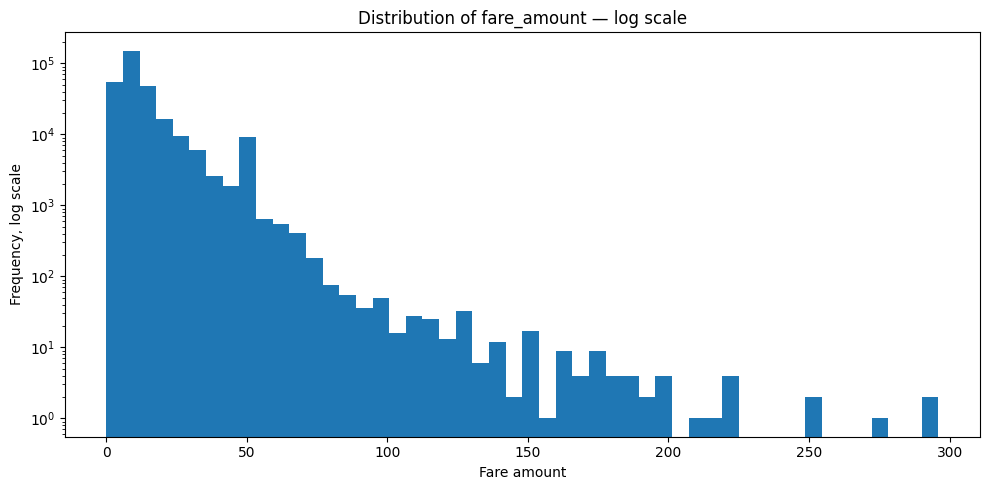

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(df_model[TARGET], bins=50)
plt.yscale("log")
plt.title("Distribution of fare_amount — log scale")
plt.xlabel("Fare amount")
plt.ylabel("Frequency, log scale")
plt.tight_layout()
plt.show()

## 5. Feature selection

The following features are used to predict `fare_amount`:

- `passenger_count`
- `trip_distance`
- `PULocationID`
- `DOLocationID`
- `payment_type`
- `RatecodeID`
- `trip_duration_minutes`
- `pickup_hour`
- `pickup_dayofweek`
- `pickup_month`

Some of these variables are numerical, while others represent categorical identifiers.

In [14]:
candidate_features = [
    "passenger_count",
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "RatecodeID",
    "trip_duration_minutes",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month"
]

features = [col for col in candidate_features if col in df_model.columns]

print("Selected features:")
for feature in features:
    print("-", feature)

print()
print("Target:", TARGET)

Selected features:
- passenger_count
- trip_distance
- PULocationID
- DOLocationID
- payment_type
- RatecodeID
- trip_duration_minutes
- pickup_hour
- pickup_dayofweek
- pickup_month

Target: fare_amount


In [15]:
ml_data = df_model[features + [TARGET]].dropna()

print("Shape before dropna:", df_model[features + [TARGET]].shape)
print("Shape after dropna:", ml_data.shape)

Shape before dropna: (300000, 11)
Shape after dropna: (300000, 11)


In [16]:
X = ml_data[features]
y_regression = ml_data[TARGET]

print("X shape:", X.shape)
print("y shape:", y_regression.shape)

X shape: (300000, 10)
y shape: (300000,)


## 6. Train/test split

The dataset is split into training and test sets.

The training set is used to fit the models.  
The test set is used to evaluate model performance on unseen data.

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X,
    y_regression,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train_reg:", y_train_reg.shape)
print("y_test_reg:", y_test_reg.shape)

X_train: (240000, 10)
X_test: (60000, 10)
y_train_reg: (240000,)
y_test_reg: (60000,)


## 7. Regression models

The first task is regression.

The models are trained to predict the continuous value of `fare_amount`.

The evaluation metrics used are:

- MAE: Mean Absolute Error
- MSE: Mean Squared Error
- RMSE: Root Mean Squared Error
- R² Score

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

In [20]:
# Optional XGBoost import

xgboost_available = False

try:
    from xgboost import XGBRegressor
    xgboost_available = True
    print("XGBoost available.")
except Exception as e:
    print("XGBoost not available:", e)

XGBoost available.


In [21]:
regression_models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=50,
        max_depth=12,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

if xgboost_available:
    regression_models["XGBRegressor"] = XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

regression_models

{'LinearRegression': LinearRegression(),
 'RandomForestRegressor': RandomForestRegressor(max_depth=12, n_estimators=50, n_jobs=-1, random_state=42),
 'XGBRegressor': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, ...)}

In [22]:
regression_results = []

for model_name, model in regression_models.items():
    print("=" * 80)
    print(f"Training regression model: {model_name}")
    
    gc.collect()
    
    start_time = time.perf_counter()
    
    model.fit(X_train, y_train_reg)
    y_pred = model.predict(X_test)
    
    end_time = time.perf_counter()
    training_time = end_time - start_time
    
    mae = mean_absolute_error(y_test_reg, y_pred)
    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, y_pred)
    
    regression_results.append({
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "task": "regression",
        "model": model_name,
        "training_time_seconds": round(training_time, 4),
        "mae": round(mae, 4),
        "mse": round(mse, 4),
        "rmse": round(rmse, 4),
        "r2_score": round(r2, 4),
        "train_rows": len(X_train),
        "test_rows": len(X_test)
    })
    
    print(f"Training time: {training_time:.4f} seconds")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print()

Training regression model: LinearRegression
Training time: 0.0311 seconds
MAE: 1.5150
RMSE: 3.8835
R²: 0.8841

Training regression model: RandomForestRegressor
Training time: 2.3635 seconds
MAE: 0.3888
RMSE: 1.8193
R²: 0.9746

Training regression model: XGBRegressor
Training time: 0.2459 seconds
MAE: 0.4133
RMSE: 1.8214
R²: 0.9745



In [23]:
regression_results_df = pd.DataFrame(regression_results)
regression_results_df

,timestamp,task,model,training_time_seconds,mae,mse,rmse,r2_score,train_rows,test_rows
0,2026-05-08 14:32:32,regression,LinearRegression,0.0311,1.5150,15.0819,3.8835,0.8841,240000,60000
1,2026-05-08 14:32:34,regression,RandomForestRegressor,2.3635,0.3888,3.3097,1.8193,0.9746,240000,60000
2,2026-05-08 14:32:34,regression,XGBRegressor,0.2459,0.4133,3.3175,1.8214,0.9745,240000,60000


## 8. Regression results visualization

The following plots compare regression model performance.

Lower MAE and RMSE are better.  
Higher R² is better.

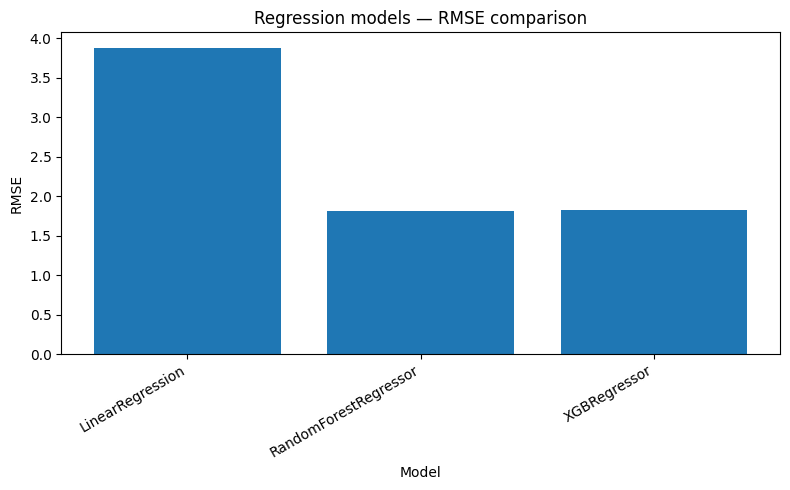

In [24]:
plt.figure(figsize=(8, 5))
plt.bar(regression_results_df["model"], regression_results_df["rmse"])
plt.title("Regression models — RMSE comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

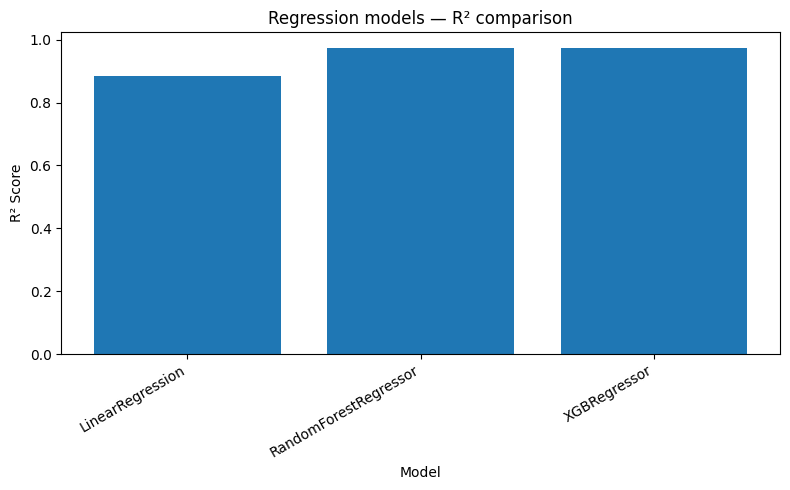

In [25]:
plt.figure(figsize=(8, 5))
plt.bar(regression_results_df["model"], regression_results_df["r2_score"])
plt.title("Regression models — R² comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 9. Classification target creation

For the classification task, the continuous `fare_amount` variable is discretized into fare classes.

The classes used are:

- `low`
- `medium`
- `high`

Quantile-based bins are used so that the classes have a more balanced distribution.

In [26]:
classification_data = ml_data.copy()

classification_data["fare_class"] = pd.qcut(
    classification_data["fare_amount"],
    q=3,
    labels=["low", "medium", "high"]
)

classification_data[["fare_amount", "fare_class"]].head()

,fare_amount,fare_class
1994593,15.0,high
587055,5.0,low
504404,11.0,medium
938230,8.5,medium
1563912,18.0,high


In [27]:
classification_data["fare_class"].value_counts()

fare_class
low       102961
medium    101334
high       95705
Name: count, dtype: int64

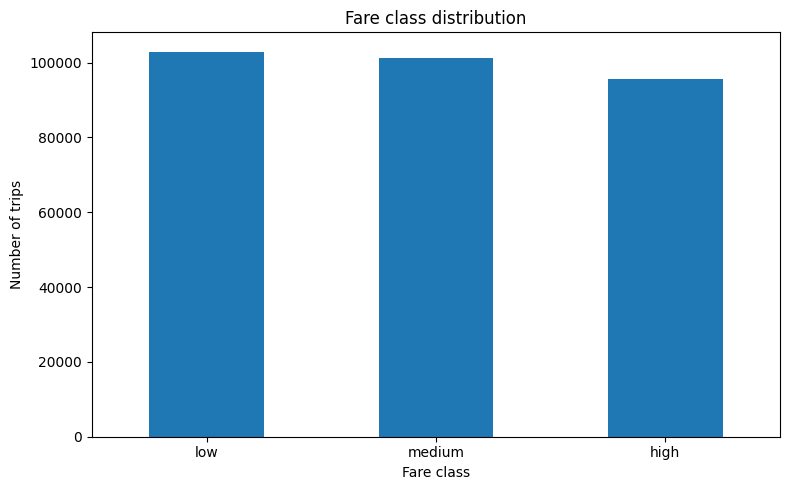

In [28]:
plt.figure(figsize=(8, 5))
classification_data["fare_class"].value_counts().sort_index().plot(kind="bar")
plt.title("Fare class distribution")
plt.xlabel("Fare class")
plt.ylabel("Number of trips")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Classification train/test split

The classification model uses the same feature set as the regression task.

The target is now `fare_class`.

In [29]:
X_cls = classification_data[features]
y_cls = classification_data["fare_class"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_cls
)

print("X_train_cls:", X_train_cls.shape)
print("X_test_cls:", X_test_cls.shape)
print("y_train_cls:", y_train_cls.shape)
print("y_test_cls:", y_test_cls.shape)

X_train_cls: (240000, 10)
X_test_cls: (60000, 10)
y_train_cls: (240000,)
y_test_cls: (60000,)


## 11. Classification models

The second task is classification.

The models are trained to predict the fare class.

The evaluation metrics used are:

- accuracy
- precision
- recall
- F1-score

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [31]:
classification_models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        n_jobs=-1
    ),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=50,
        max_depth=12,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

classification_models

{'LogisticRegression': LogisticRegression(max_iter=1000, n_jobs=-1),
 'RandomForestClassifier': RandomForestClassifier(max_depth=12, n_estimators=50, n_jobs=-1,
                        random_state=42)}

In [32]:
classification_results = []
classification_predictions = {}

for model_name, model in classification_models.items():
    print("=" * 80)
    print(f"Training classification model: {model_name}")
    
    gc.collect()
    
    start_time = time.perf_counter()
    
    model.fit(X_train_cls, y_train_cls)
    y_pred_cls = model.predict(X_test_cls)
    
    end_time = time.perf_counter()
    training_time = end_time - start_time
    
    accuracy = accuracy_score(y_test_cls, y_pred_cls)
    precision = precision_score(y_test_cls, y_pred_cls, average="weighted")
    recall = recall_score(y_test_cls, y_pred_cls, average="weighted")
    f1 = f1_score(y_test_cls, y_pred_cls, average="weighted")
    
    classification_results.append({
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "task": "classification",
        "model": model_name,
        "training_time_seconds": round(training_time, 4),
        "accuracy": round(accuracy, 4),
        "precision_weighted": round(precision, 4),
        "recall_weighted": round(recall, 4),
        "f1_weighted": round(f1, 4),
        "train_rows": len(X_train_cls),
        "test_rows": len(X_test_cls)
    })
    
    classification_predictions[model_name] = y_pred_cls
    
    print(f"Training time: {training_time:.4f} seconds")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision weighted: {precision:.4f}")
    print(f"Recall weighted: {recall:.4f}")
    print(f"F1 weighted: {f1:.4f}")
    print()

Training classification model: LogisticRegression
Training time: 11.2458 seconds
Accuracy: 0.8574
Precision weighted: 0.8592
Recall weighted: 0.8574
F1 weighted: 0.8580

Training classification model: RandomForestClassifier
Training time: 1.1997 seconds
Accuracy: 0.9685
Precision weighted: 0.9688
Recall weighted: 0.9685
F1 weighted: 0.9686



In [33]:
classification_results_df = pd.DataFrame(classification_results)
classification_results_df

,timestamp,task,model,training_time_seconds,accuracy,precision_weighted,recall_weighted,f1_weighted,train_rows,test_rows
0,2026-05-08 14:35:38,classification,LogisticRegression,11.2458,0.8574,0.8592,0.8574,0.8580,240000,60000
1,2026-05-08 14:35:40,classification,RandomForestClassifier,1.1997,0.9685,0.9688,0.9685,0.9686,240000,60000


## 12. Classification reports

The classification report shows precision, recall and F1-score for each fare class.

In [34]:
for model_name, y_pred_cls in classification_predictions.items():
    print("=" * 80)
    print(f"Classification report — {model_name}")
    print("=" * 80)
    print(classification_report(y_test_cls, y_pred_cls))
    print()

Classification report — LogisticRegression
              precision    recall  f1-score   support

        high       0.93      0.88      0.90     19141
         low       0.87      0.88      0.88     20592
      medium       0.78      0.81      0.80     20267

    accuracy                           0.86     60000
   macro avg       0.86      0.86      0.86     60000
weighted avg       0.86      0.86      0.86     60000


Classification report — RandomForestClassifier
              precision    recall  f1-score   support

        high       0.98      0.98      0.98     19141
         low       0.98      0.97      0.97     20592
      medium       0.94      0.96      0.95     20267

    accuracy                           0.97     60000
   macro avg       0.97      0.97      0.97     60000
weighted avg       0.97      0.97      0.97     60000




## 13. Confusion matrices

The confusion matrix shows how many observations were correctly or incorrectly classified for each fare class.

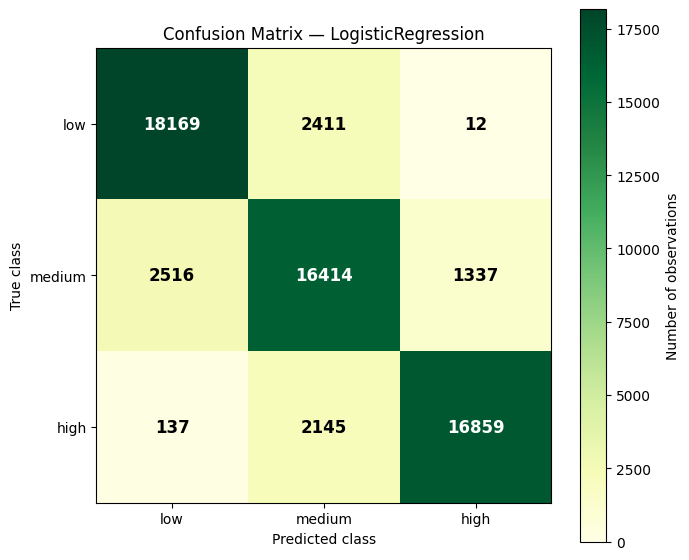

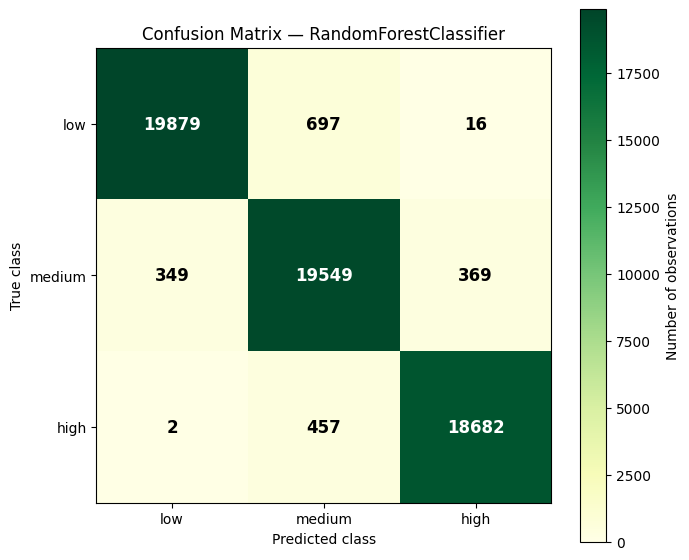

In [37]:
class_labels = ["low", "medium", "high"]

for model_name, y_pred_cls in classification_predictions.items():
    cm = confusion_matrix(y_test_cls, y_pred_cls, labels=class_labels)

    plt.figure(figsize=(7, 6))
    im = plt.imshow(cm, cmap="YlGn", vmin=0, vmax=cm.max())

    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.xticks(ticks=np.arange(len(class_labels)), labels=class_labels)
    plt.yticks(ticks=np.arange(len(class_labels)), labels=class_labels)

    plt.colorbar(im, label="Number of observations")

    threshold = cm.max() / 2

    for i in range(len(class_labels)):
        for j in range(len(class_labels)):
            plt.text(
                j, i, f"{cm[i, j]}",
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=12,
                fontweight="bold"
            )

    plt.tight_layout()
    plt.show()

## 14. Classification results visualization

The following plots compare the classification models using accuracy and F1-score.

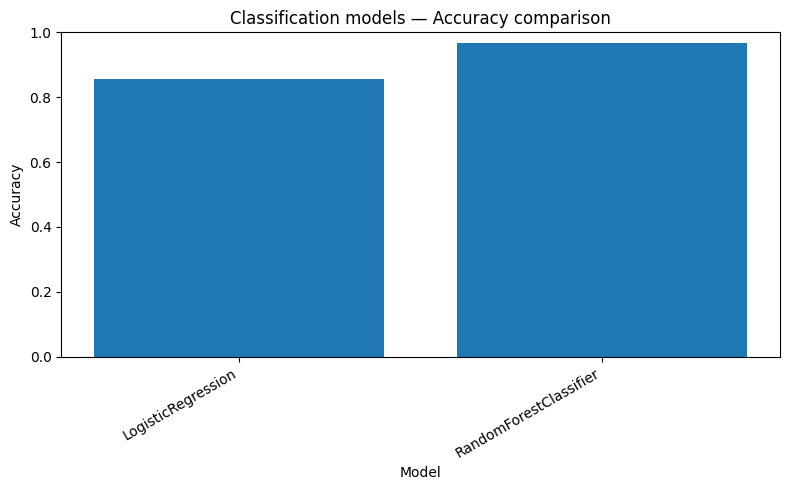

In [38]:
plt.figure(figsize=(8, 5))
plt.bar(classification_results_df["model"], classification_results_df["accuracy"])
plt.title("Classification models — Accuracy comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

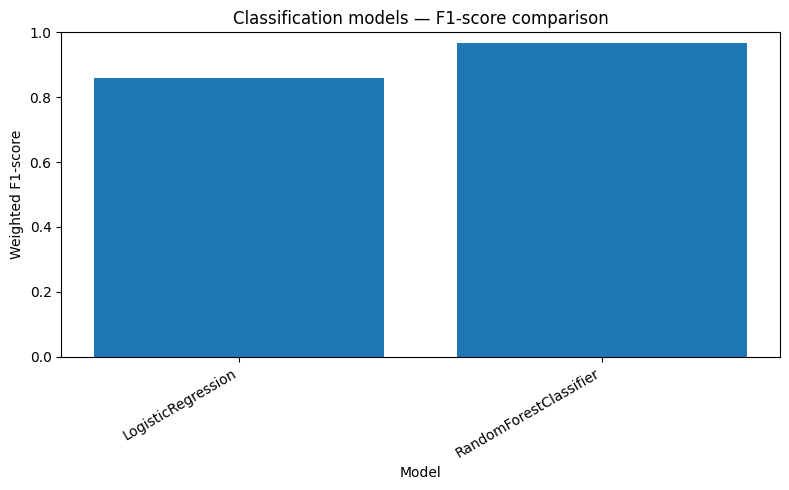

In [39]:
plt.figure(figsize=(8, 5))
plt.bar(classification_results_df["model"], classification_results_df["f1_weighted"])
plt.title("Classification models — F1-score comparison")
plt.xlabel("Model")
plt.ylabel("Weighted F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 15. Feature importance

Tree-based models can provide feature importance values.

This helps understand which variables contributed most to the predictions.

In [40]:
feature_importance_tables = []

for model_name, model in regression_models.items():
    if hasattr(model, "feature_importances_"):
        importance_df = pd.DataFrame({
            "task": "regression",
            "model": model_name,
            "feature": features,
            "importance": model.feature_importances_
        }).sort_values("importance", ascending=False)
        
        feature_importance_tables.append(importance_df)

for model_name, model in classification_models.items():
    if hasattr(model, "feature_importances_"):
        importance_df = pd.DataFrame({
            "task": "classification",
            "model": model_name,
            "feature": features,
            "importance": model.feature_importances_
        }).sort_values("importance", ascending=False)
        
        feature_importance_tables.append(importance_df)

if len(feature_importance_tables) > 0:
    feature_importance_df = pd.concat(feature_importance_tables, ignore_index=True)
else:
    feature_importance_df = pd.DataFrame(columns=["task", "model", "feature", "importance"])

feature_importance_df

,task,model,feature,importance
0,regression,RandomForestRegressor,trip_distance,0.891637
1,regression,RandomForestRegressor,trip_duration_minutes,0.051382
2,regression,RandomForestRegressor,RatecodeID,0.043388
3,regression,RandomForestRegressor,DOLocationID,0.005850
4,regression,RandomForestRegressor,pickup_hour,0.002673
5,regression,RandomForestRegressor,PULocationID,0.002445
6,regression,RandomForestRegressor,pickup_dayofweek,0.001028
7,regression,RandomForestRegressor,passenger_count,0.000814
8,regression,RandomForestRegressor,payment_type,0.000782
9,regression,RandomForestRegressor,pickup_month,0.000000


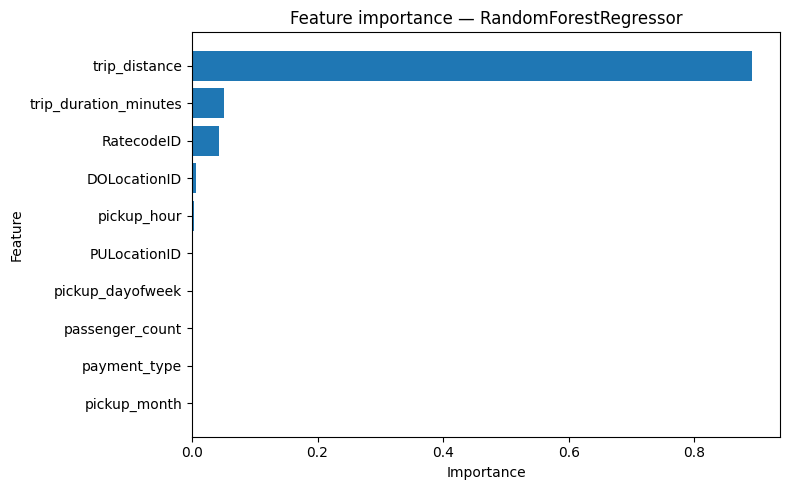

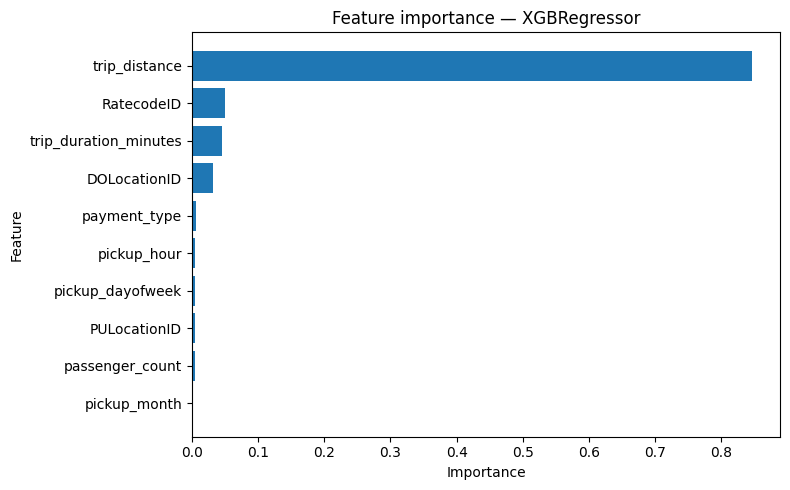

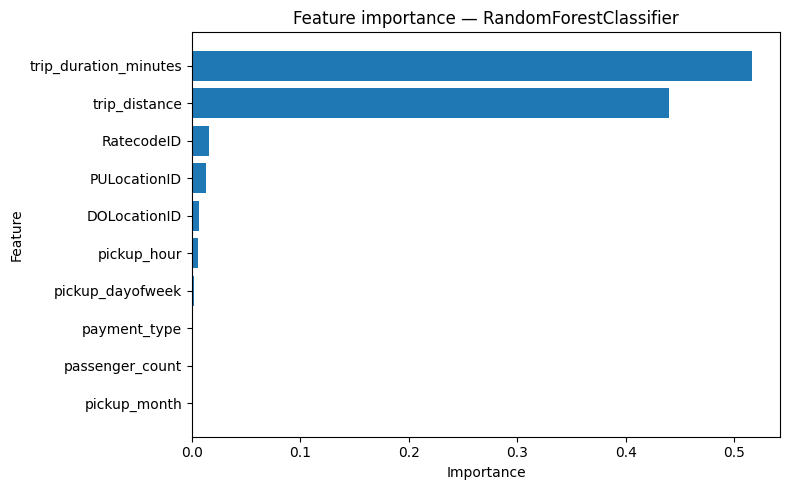

In [41]:
for model_name in feature_importance_df["model"].unique():
    plot_data = feature_importance_df[
        feature_importance_df["model"] == model_name
    ].sort_values("importance", ascending=True)
    
    plt.figure(figsize=(8, 5))
    plt.barh(plot_data["feature"], plot_data["importance"])
    plt.title(f"Feature importance — {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

## 16. Save machine learning results

The generated metrics are saved as CSV files so they can be used in the final report.

In [42]:
regression_results_path = RESULTS_DIR / "ml_regression_results.csv"
classification_results_path = RESULTS_DIR / "ml_classification_results.csv"
feature_importance_path = RESULTS_DIR / "ml_feature_importance.csv"

regression_results_df.to_csv(regression_results_path, index=False)
classification_results_df.to_csv(classification_results_path, index=False)
feature_importance_df.to_csv(feature_importance_path, index=False)

print("Saved files:")
print(regression_results_path)
print(classification_results_path)
print(feature_importance_path)

Saved files:
/Users/nunoantunes/Desktop/nyc_taxi_project/results/ml_regression_results.csv
/Users/nunoantunes/Desktop/nyc_taxi_project/results/ml_classification_results.csv
/Users/nunoantunes/Desktop/nyc_taxi_project/results/ml_feature_importance.csv


## 17. Save combined model summary

A combined summary table is created to compare all trained models in a single file.

In [43]:
regression_summary = regression_results_df.copy()
classification_summary = classification_results_df.copy()

for col in ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]:
    if col not in regression_summary.columns:
        regression_summary[col] = np.nan

for col in ["mae", "mse", "rmse", "r2_score"]:
    if col not in classification_summary.columns:
        classification_summary[col] = np.nan

common_columns = [
    "timestamp",
    "task",
    "model",
    "training_time_seconds",
    "mae",
    "mse",
    "rmse",
    "r2_score",
    "accuracy",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "train_rows",
    "test_rows"
]

ml_summary_df = pd.concat(
    [
        regression_summary[common_columns],
        classification_summary[common_columns]
    ],
    ignore_index=True
)

ml_summary_df

,timestamp,task,model,training_time_seconds,mae,mse,rmse,r2_score,accuracy,precision_weighted,recall_weighted,f1_weighted,train_rows,test_rows
0,2026-05-08 14:32:32,regression,LinearRegression,0.0311,1.5150,15.0819,3.8835,0.8841,NaN,NaN,NaN,NaN,240000,60000
1,2026-05-08 14:32:34,regression,RandomForestRegressor,2.3635,0.3888,3.3097,1.8193,0.9746,NaN,NaN,NaN,NaN,240000,60000
2,2026-05-08 14:32:34,regression,XGBRegressor,0.2459,0.4133,3.3175,1.8214,0.9745,NaN,NaN,NaN,NaN,240000,60000
3,2026-05-08 14:35:38,classification,LogisticRegression,11.2458,NaN,NaN,NaN,NaN,0.8574,0.8592,0.8574,0.8580,240000,60000
4,2026-05-08 14:35:40,classification,RandomForestClassifier,1.1997,NaN,NaN,NaN,NaN,0.9685,0.9688,0.9685,0.9686,240000,60000


In [44]:
ml_summary_path = RESULTS_DIR / "ml_model_summary.csv"

ml_summary_df.to_csv(ml_summary_path, index=False)

print("Combined ML summary saved to:", ml_summary_path)

Combined ML summary saved to: /Users/nunoantunes/Desktop/nyc_taxi_project/results/ml_model_summary.csv


## 18. Discussion notes

The results of this notebook can be discussed using the following points:

1. Regression models predict the actual numerical fare amount.
2. Classification models predict a fare category after discretizing the target variable.
3. Linear Regression is fast and simple, but may not capture non-linear relationships.
4. Random Forest can capture non-linear patterns but may require more training time.
5. XGBoost, when available, is often competitive for tabular prediction tasks.
6. `trip_distance` and `trip_duration_minutes` are among the most important predictors.
7. Classification metrics should be analyzed using accuracy, precision, recall and F1-score.
8. Regression metrics should be analyzed using MAE, RMSE and R².

In [46]:
print("Notebook 03 completed successfully.")
print("Machine learning results saved in:", RESULTS_DIR)

Notebook 03 completed successfully.
Machine learning results saved in: /Users/nunoantunes/Desktop/nyc_taxi_project/results
